In [7]:
import pandas as pd

# 1. Load your financial data
# Replace 'financial_returns.csv' with your actual file path (CSV, Excel, etc.)
# We assume dates are in the first column and set them as the index

df = pd.read_csv('./data/concat_hf_data.csv', parse_dates=True).set_index('date')
# 2. Compute the correlation matrix
# 'min_periods' ensures we have at least N overlapping data points 
# to trust the correlation score. Adjust this based on your dataset size.
corr_matrix = df.corr(method='pearson', min_periods=3)

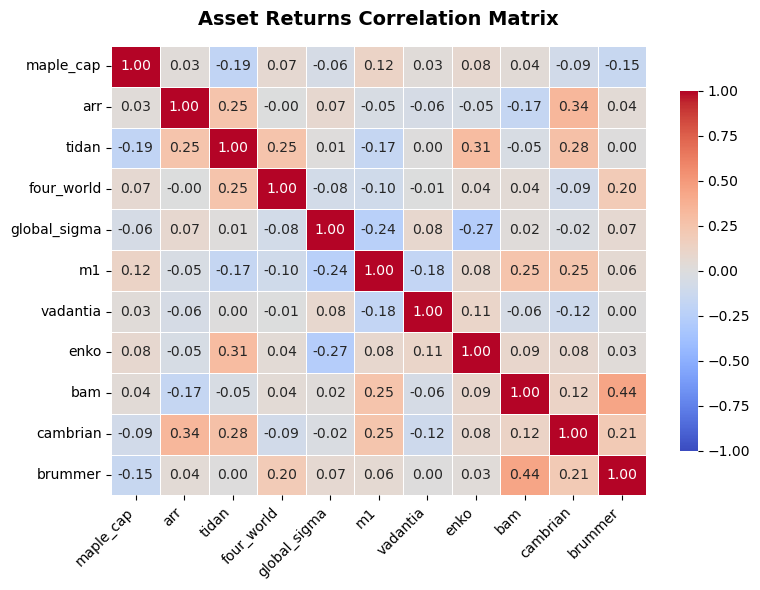

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# # 1. Assuming you already have your correlation matrix from the previous step
# # (We will use mock data here just so the script runs standalone)
# np.random.seed(42)
# columns = ['Gold', 'S&P 500', 'US 10Y Bond', 'Bitcoin', 'Crude Oil']
# mock_data = pd.DataFrame(np.random.randn(100, 5), columns=columns)
# corr_matrix = mock_data.corr()

# 2. Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# 3. Create a mask to hide the upper triangle (optional, but cleaner)
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Generate a custom diverging colormap (Coolwarm is great for correlations)
# It maps -1 to deep blue, 0 to white/gray, and +1 to deep red
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# 5. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    # mask=mask,          # Applies the upper-triangle mask
    cmap='coolwarm',    # Good color scale for -1 to 1 ranges
    vmax=1.0,           # Anchor the maximum value of the scale
    vmin=-1.0,          # Anchor the minimum value of the scale
    center=0,           # Center the colorbar at 0
    annot=True,         # Write the correlation numbers inside the squares
    fmt=".2f",          # Limit numbers to 2 decimal places
    linewidths=0.5,     # Add thin lines between the squares
    cbar_kws={"shrink": 0.8} # Slightly shrink the colorbar so it fits nicely
)

plt.title('Asset Returns Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right') # Rotate asset labels so they don't overlap
plt.yticks(rotation=0)

# 6. Show or save the plot
plt.tight_layout()
plt.show()
# plt.savefig('correlation_heatmap.png', dpi=300) # Uncomment to save